<a href="https://colab.research.google.com/github/KhushnurAnjum26/machine-Learning/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Final Project


In [94]:
 !pip install -U git+https://github.com/qubvel/segmentation_models.pytorch # for installing segmentation models

  Cloning https://github.com/qubvel/segmentation_models.pytorch to /tmp/pip-req-build-1tp4vcy7
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/segmentation_models.pytorch /tmp/pip-req-build-1tp4vcy7
  Resolved https://github.com/qubvel/segmentation_models.pytorch to commit 1fd0be2aa961eb885f06ed492cfb26f9f4c2e231
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Import Libraries


In [95]:
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import torch
from torch.utils.data import DataLoader
from torch import nn
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.utils.train import TrainEpoch, ValidEpoch
import random
import os
import random
import shutil
import albumentations as album
from timeit import default_timer as timer
import matplotlib.pyplot as plt

## Load Dataset


#### Extract dataset


I have loaded a zip file of the dataset `(kvasir-seg.zip)` onto Google Drive, and now I want to unzip it.


In [96]:
import zipfile
import os

zip_path = "/content/Kvasir-SEG.zip"
extract_path = "/content/kvasir-seg_extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: /content/kvasir-seg_extracted


In [97]:
!find /content/kvasir-seg_extracted -type d | head -20

/content/kvasir-seg_extracted
/content/kvasir-seg_extracted/Kvasir-SEG
/content/kvasir-seg_extracted/Kvasir-SEG/validation
/content/kvasir-seg_extracted/Kvasir-SEG/validation/images
/content/kvasir-seg_extracted/Kvasir-SEG/validation/masks
/content/kvasir-seg_extracted/Kvasir-SEG/images
/content/kvasir-seg_extracted/Kvasir-SEG/masks
/content/kvasir-seg_extracted/Kvasir-SEG/test
/content/kvasir-seg_extracted/Kvasir-SEG/test/images
/content/kvasir-seg_extracted/Kvasir-SEG/test/masks
/content/kvasir-seg_extracted/Kvasir-SEG/train
/content/kvasir-seg_extracted/Kvasir-SEG/train/images
/content/kvasir-seg_extracted/Kvasir-SEG/train/masks


#### Load images and masks


This class is implemented to load all images and masks.


In [98]:
import glob
import cv2

class LoadDataset:

    INPUT_IMAGES_DIR = "/content/kvasir-seg_extracted/Kvasir-SEG/images/*.jpg"
    INPUT_MASKS_DIR  = "/content/kvasir-seg_extracted/Kvasir-SEG/masks/*.jpg"

    def __init__(self):
        self.images = self.__load_images(self.INPUT_IMAGES_DIR)
        self.masks = self.__load_masks(self.INPUT_MASKS_DIR)

    def __load_images(self, path):
        data = []
        for img in glob.glob(path):
            data.append(cv2.imread(img))
        return data

    def __load_masks(self, path):
        data = []
        for img in glob.glob(path):
            data.append(cv2.imread(img, cv2.IMREAD_GRAYSCALE))
        return data

In [99]:
dataset = LoadDataset()

print(len(dataset.images))
print(len(dataset.masks))

1000
1000


## Dataset Familiarization And Visualization


#### Basic information about the input images


In [100]:
print("Size of dataset : ", len(dataset.images))

print("Input images shape : ", dataset.images[0].shape)

print("Input masks shape : ", dataset.masks[0].shape)

Size of dataset :  1000
Input images shape :  (546, 624, 3)
Input masks shape :  (546, 624)


#### Visualize some samples of polyp images


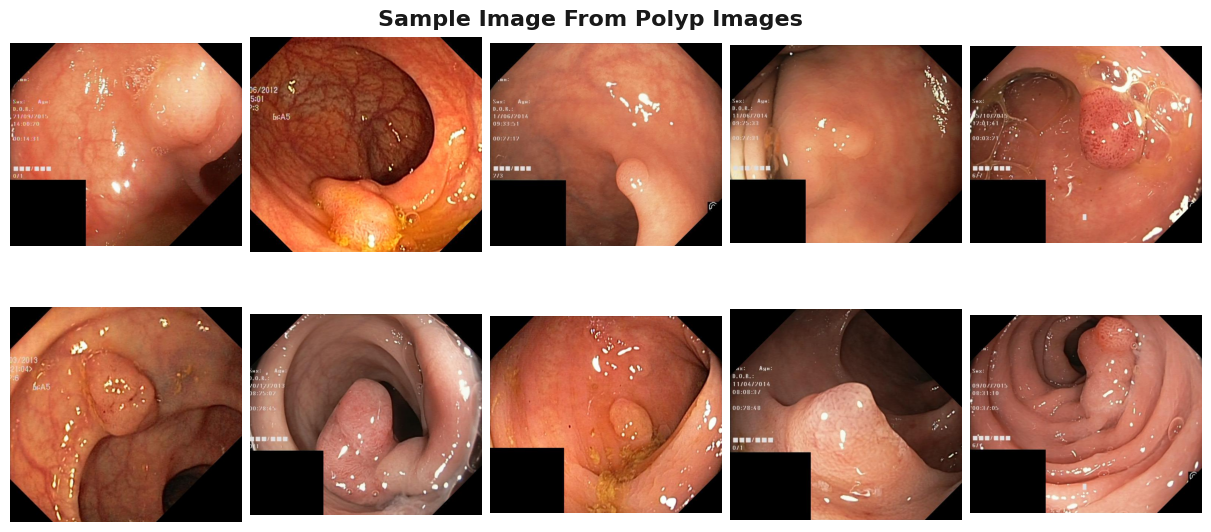

In [101]:
fig, axs = plt.subplots(2, 5, figsize=(12, 5.4), constrained_layout=True)
fig.text(s='Sample Image From Polyp Images', size=16, fontweight='bold',
         y=0.97, x=0.31, alpha=0.9)
axs = axs.flatten()
for img, ax in zip(input.images[:10], axs):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.show()

#### Visualize Ployps vs. Masks


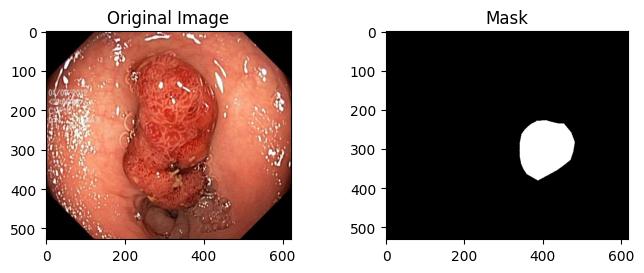

In [102]:
plt.figure(figsize=(8, 2.7))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(dataset.images[10], cv2.COLOR_BGR2RGB))
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(dataset.masks[11], cmap='gray')
plt.title("Mask")
plt.show()

## Preparing Data


#### Split data


If you have run this code before, please execute it again to remove old directories.


In [103]:
import os
import shutil

base_path = "/content/kvasir-seg_extracted/Kvasir-SEG"

train_dir = os.path.join(base_path, "train")
test_dir = os.path.join(base_path, "test")
validation_dir = os.path.join(base_path, "validation")

if os.path.exists(train_dir):
    shutil.rmtree(train_dir)
if os.path.exists(test_dir):
    shutil.rmtree(test_dir)
if os.path.exists(validation_dir):
    shutil.rmtree(validation_dir)

In this section, I aim to randomly split the input images into three parts: one for training images, where you can specify the desired volume; another for validation images, and finally, a section for testing.


In [104]:
# Define the paths
source_dir = "/content/kvasir-seg_extracted/Kvasir-SEG"
images_dir = os.path.join(source_dir, "images")
masks_dir = os.path.join(source_dir, "masks")
output_dir = "/content/kvasir-seg_extracted/Kvasir-SEG"

# Create output folders for training, validation, and test sets
train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "validation")
test_dir = os.path.join(output_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Function to copy files from source to destination

def copy_files(file_list, source_folder, dest_folder):
    for file in file_list:
        shutil.copy(file, dest_folder)


# List all images and masks
images = [os.path.join(images_dir, f) for f in os.listdir(
    images_dir) if os.path.isfile(os.path.join(images_dir, f))]
masks = [os.path.join(masks_dir, f) for f in os.listdir(
    masks_dir) if os.path.isfile(os.path.join(masks_dir, f))]


temp = list(zip(images, masks))
random.shuffle(temp)
images, masks = zip(*temp)
images, masks = list(images), list(masks)

# Define ratios for train, validation, and test sets (e.g., 60%, 20%, 20%)
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Split the data
train_split = int(len(images) * train_ratio)
val_split = int(len(images) * (train_ratio + val_ratio))

train_images = images[:train_split]
val_images = images[train_split:val_split]
test_images = images[val_split:]

train_masks = masks[:train_split]
val_masks = masks[train_split:val_split]
test_masks = masks[val_split:]

# Create subdirectories for images and masks
os.makedirs(os.path.join(train_dir, "images"), exist_ok=True)
os.makedirs(os.path.join(train_dir, "masks"), exist_ok=True)
os.makedirs(os.path.join(val_dir, "images"), exist_ok=True)
os.makedirs(os.path.join(val_dir, "masks"), exist_ok=True)
os.makedirs(os.path.join(test_dir, "images"), exist_ok=True)
os.makedirs(os.path.join(test_dir, "masks"), exist_ok=True)

# Copy images and masks to respective folders
copy_files(train_images, images_dir, os.path.join(train_dir, "images"))
copy_files(val_images, images_dir, os.path.join(val_dir, "images"))
copy_files(test_images, images_dir, os.path.join(test_dir, "images"))

copy_files(train_masks, masks_dir, os.path.join(train_dir, "masks"))
copy_files(val_masks, masks_dir, os.path.join(val_dir, "masks"))
copy_files(test_masks, masks_dir, os.path.join(test_dir, "masks"))

print("Data split and copied successfully.")

Data split and copied successfully.


#### Encode Masks


`one_hot_encode` : Converts a segmentation label map to one-hot encoded format based on the provided label values.

`reverse_one_hot` : Converts a one-hot encoded segmentation map back to a single-channel segmentation label map.

`color_code_segmentation` : Converts a single-channel segmentation label map to a color-coded segmentation map based on the provided label values.


In [105]:
def one_hot_encode(label, label_values):
    semantic_map = []
    for color in label_values:
        equality = np.equal(label, color)
        class_map = np.all(equality, axis=-1)
        semantic_map.append(class_map)
    semantic_map = np.stack(semantic_map, axis=-1)

    return semantic_map


def reverse_one_hot(image):
    x = np.argmax(image, axis=-1)
    return x


def color_code_segmentation(image, label_values):
    color_codes = np.array(label_values)
    x = color_codes[image.astype(int)]

    return x

#### A custom PyTorch dataset


A custom PyTorch dataset class for handling image and mask data.


In [106]:
class TorchDataset(torch.utils.data.Dataset):
    def __init__(
            self,
            df,
            class_rgb_values=None,
            augmentation=None,
            preprocessing=None,
    ):
        self.image_paths = df['image_path'].tolist()
        self.mask_paths = df['mask_path'].tolist()

        self.class_rgb_values = class_rgb_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def __getitem__(self, i):
        image = cv2.cvtColor(cv2.imread(
            self.image_paths[i]), cv2.COLOR_BGR2RGB)
        mask = cv2.cvtColor(cv2.imread(self.mask_paths[i]), cv2.COLOR_BGR2RGB)

        mask = one_hot_encode(mask, self.class_rgb_values).astype('float')

        # apply augmentations, you should this in init
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        # apply preprocessing, you should set it in init
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        return image, mask

    def __len__(self):
        return len(self.image_paths)

A helper function for visualizing images


In [107]:
def visualize(**images):
    n_images = len(images)
    plt.figure(figsize=(20, 8))
    for idx, (name, image) in enumerate(images.items()):
        plt.subplot(1, n_images, idx + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(name.replace('_', ' ').title())
        if (name == 'ground_truth_mask'):
            plt.imshow(image, cmap='gray')
        else:
            plt.imshow(image)

    plt.show()

#### Load Trian data


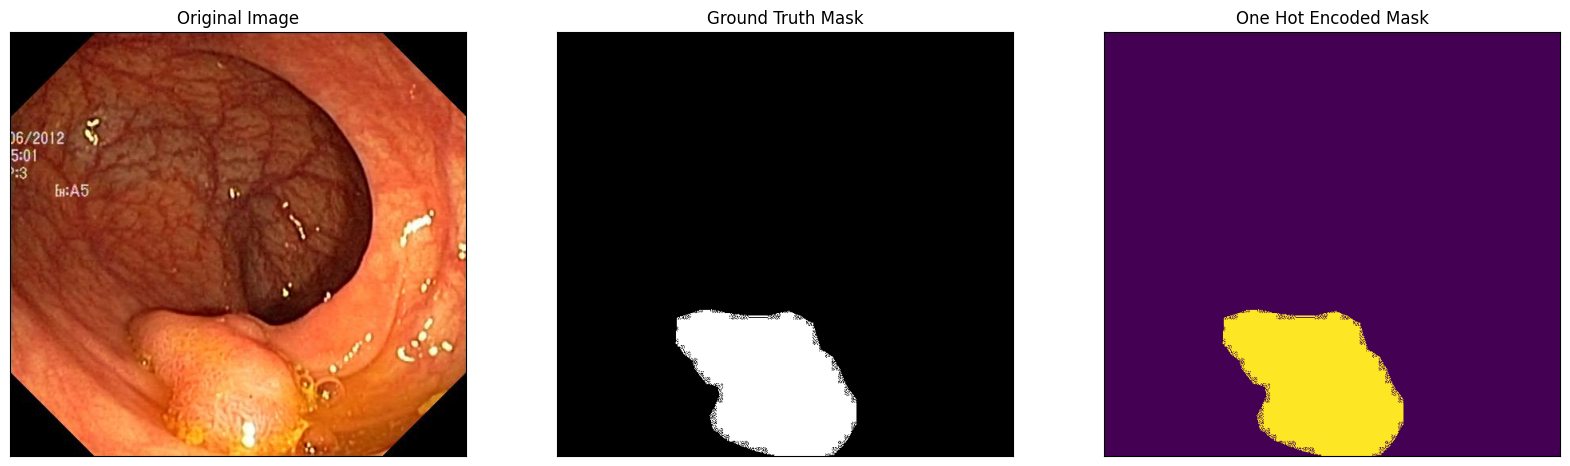

In [108]:
dataset_root_train = '/content/kvasir-seg_extracted/Kvasir-SEG/train'

images_dir = os.path.join(dataset_root_train, 'images')
masks_dir = os.path.join(dataset_root_train, 'masks')

image_paths = [os.path.join(images_dir, filename)
               for filename in os.listdir(images_dir)]
masks_paths = [os.path.join(masks_dir, filename)
               for filename in os.listdir(masks_dir)]

df_train = pd.DataFrame({'image_path': image_paths, 'mask_path': masks_paths})

dataset = TorchDataset(df_train, class_rgb_values=(0, 255))

image, mask = dataset[1]

visualize(
    original_image=image,
    ground_truth_mask=color_code_segmentation(
        reverse_one_hot(mask), (0, 255)),
    one_hot_encoded_mask=reverse_one_hot(mask)
)

## Preprocessing


`get_training_augmentation` : Returns a set of augmentation transformations for training data.

`get_validation_augmentation` : Returns a set of augmentation transformations for validation data.

`to_tensor` : Converts an image array to a PyTorch tensor.

`get_preprocessing` : Returns a set of preprocessing transformations.


In [109]:
def get_training_augmentation():
    train_transform = [
        album.Resize(height=512, width=608,
                     interpolation=cv2.INTER_CUBIC, always_apply=True),
        album.HorizontalFlip(p=0.5),
        album.VerticalFlip(p=0.5),
    ]
    return album.Compose(train_transform)


def get_validation_augmentation():
    test_transform = [
        album.Resize(height=512, width=608,
                     interpolation=cv2.INTER_CUBIC, always_apply=True),
    ]
    return album.Compose(test_transform)


def to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')


def get_preprocessing(preprocessing_fn=None):
    _transform = []
    if preprocessing_fn:
        _transform.append(album.Lambda(image=preprocessing_fn))
    _transform.append(album.Lambda(image=to_tensor, mask=to_tensor))

    return album.Compose(_transform)

#### Visualize processed data


/tmp/ipykernel_803/1227201389.py:3: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(height=512, width=608,


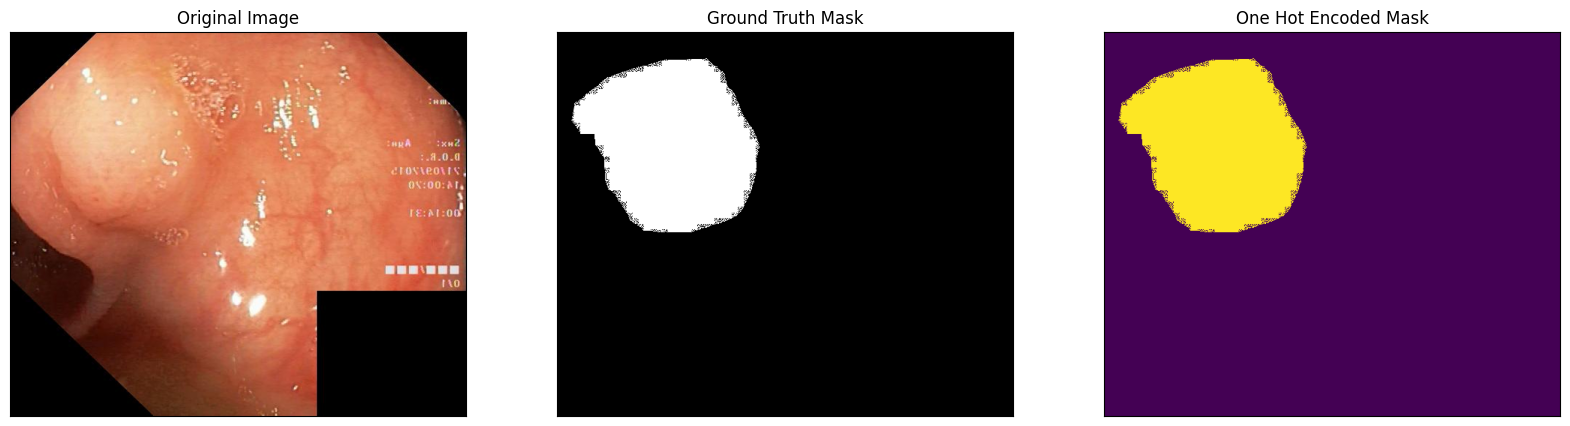

In [110]:
augmented_dataset = TorchDataset(
    df_train,
    augmentation=get_training_augmentation(),
    class_rgb_values=(0, 255),
)

random_idx = random.randint(0, len(augmented_dataset)-1)

# Different augmentations on image/mask pairs
for idx in range(1):
    image, mask = augmented_dataset[idx]
    visualize(
        original_image=image,
        ground_truth_mask=color_code_segmentation(
            reverse_one_hot(mask), (0, 255)),
        one_hot_encoded_mask=reverse_one_hot(mask)
    )

## Models Implementations


This class serves as a foundational framework for training and evaluating various segmentation models for polyp detection.

##### Attributes

- `CLASSES`: A list defining the classes for segmentation.
- `ACTIVATION`: Activation function used in the models.
- `DATASET_VALIDATION_ROOT_DIR`: Root directory for the validation dataset.
- `DATASET_TEST_ROOT_DIR`: Root directory for the test dataset.

##### Methods

`__init__(self, model_name, model, encoder)`

- **Parameters:**
  - `model_name`: Name of the model.
  - `model`: Segmentation model.
  - `encoder`: Encoder for the model.
- **Description:** Initializes the BaseModel class with the provided parameters.

`init_model(self, encoder_weights='imagenet')`

- **Parameters:**
  - `encoder_weights`: Weights for the encoder.
- **Description:** Initializes the segmentation model.

`build_trian_and_valid_loader(self, batch_size=16)`

- **Parameters:**
  - `batch_size`: Batch size for data loading.
- **Description:** Builds training and validation data loaders.

`set_model_training_params(self, n_epoch=10)`

- **Parameters:**
  - `n_epoch`: Number of epochs for training.
- **Description:** Sets training parameters including loss, metrics, optimizer, and learning rate scheduler.

`init_train_and_valid_epoch(self)`

- **Description:** Initializes training and validation epochs.

`train(self)`

- **Description:** Trains the model.

`load_best_model(self)`

- **Description:** Loads the best-performing model.

`load_testset_and_visualize(self)`

- **Description:** Loads the test dataset and visualizes results.

`evaluation(self)`

- **Description:** Evaluates model performance on test data.

`visualize_train__loss_vs_score(self)`

- **Description:** Visualizes training loss vs. score.

`plot_iou_score_during_training(self)`

- **Description:** Plots IoU score during training.

`plot_dice_loss_during_training(self)`

- **Description:** Plots Dice loss during training.

`visualize_predicted_result(self)`

- **Description:** Visualizes predicted results.


In [111]:
class BaseModel:

    CLASSES = ['polyp', 'background']
    ACTIVATION = 'sigmoid'

    DATASET_VALIDATION_ROOT_DIR = '/content/kvasir-seg_extracted/Kvasir-SEG/validation'
    DATASET_TEST_ROOT_DIR = '/content/kvasir-seg_extracted/Kvasir-SEG/test'

    def __init__(self, model_name, model, encoder) -> None:
        self.model = model
        self.encoder = encoder
        self.model_name = model_name

    def init_model(self, encoder_weights='imagenet'):

        self.model = self.model(
            encoder_name=self.encoder,
            encoder_weights=encoder_weights,
            classes=len(self.CLASSES),
            activation=self.ACTIVATION,
        )

        self.preprocessing_fn = smp.encoders.get_preprocessing_fn(
            self.encoder, encoder_weights)

    def build_trian_and_valid_loader(self, batch_size=16):
        # Get train and val dataset instances
        train_dataset = TorchDataset(
            df_train,
            augmentation=get_training_augmentation(),
            preprocessing=get_preprocessing(self.preprocessing_fn),
            class_rgb_values=(0, 255),
        )

        images_dir = os.path.join(self.DATASET_VALIDATION_ROOT_DIR, 'images')
        masks_dir = os.path.join(self.DATASET_VALIDATION_ROOT_DIR, 'masks')

        image_paths = [os.path.join(images_dir, filename)
                       for filename in os.listdir(images_dir)]
        masks_paths = [os.path.join(masks_dir, filename)
                       for filename in os.listdir(masks_dir)]

        df_val = pd.DataFrame(
            {'image_path': image_paths, 'mask_path': masks_paths})

        valid_dataset = TorchDataset(
            df_val,
            augmentation=get_validation_augmentation(),
            preprocessing=get_preprocessing(self.preprocessing_fn),
            class_rgb_values=(0, 255),
        )

        # Get train and val data loaders
        self.train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True)
        self.valid_loader = DataLoader(
            valid_dataset, batch_size=batch_size, shuffle=False)

    def set_model_training_params(self, n_epoch=10):
        # Set flag to train the model or not. If set to 'False', only prediction is performed (using an older model checkpoint)
        self.TRAINING = True

        # Set num of epochs
        self.EPOCHS = n_epoch

        # Set device: `cuda` or `cpu`
        self.DEVICE = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu")

        # define loss function
        self.loss = smp.utils.losses.DiceLoss()

        # define metrics
        self.metrics = [
            smp.utils.metrics.IoU(threshold=0.5),
        ]

        # define optimizer
        self.optimizer = torch.optim.Adam([
            dict(params=self.model.parameters(), lr=0.0001),
        ])

        # define learning rate scheduler (not used in this NB)
        self.lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=1, T_mult=2, eta_min=5e-5,
        )

    def init_train_and_valid_epoch(self):
        self.train_epoch = TrainEpoch(
            self.model,
            loss=self.loss,
            metrics=self.metrics,
            optimizer=self.optimizer,
            device=self.DEVICE,
            verbose=True,
        )

        self.valid_epoch = ValidEpoch(
            self.model,
            loss=self.loss,
            metrics=self.metrics,
            device=self.DEVICE,
            verbose=True,
        )

    def train(self):
        start_time = timer()

        self.train_logs_list, self.valid_logs_list = [], []
        best_iou_score = 0.0

        for i in range(0, self.EPOCHS):

            # Perform training & validation
            print('\nEpoch: {}'.format(i))
            train_logs = self.train_epoch.run(self.train_loader)
            valid_logs = self.valid_epoch.run(self.valid_loader)
            self.train_logs_list.append(train_logs)
            self.valid_logs_list.append(valid_logs)

            # Save model if a better val IoU score is obtained
            if best_iou_score < valid_logs['iou_score']:
                best_iou_score = valid_logs['iou_score']
                torch.save(self.model, './' +
                           self.model_name + '_best_model.pth')
                print('Model saved!')

        print((timer() - start_time) / 60, "minuates")

    def load_best_model(self):
        self.best_model = torch.load(
            '/content/' + self.model_name + '_best_model.pth', map_location=self.DEVICE)

    def load_testset_and_visualize(self):
        images_dir = os.path.join(self.DATASET_TEST_ROOT_DIR, 'images')
        masks_dir = os.path.join(self.DATASET_TEST_ROOT_DIR, 'masks')

        image_paths = [os.path.join(images_dir, filename)
                       for filename in os.listdir(images_dir)]
        masks_paths = [os.path.join(masks_dir, filename)
                       for filename in os.listdir(masks_dir)]

        df_test = pd.DataFrame(
            {'image_path': image_paths, 'mask_path': masks_paths})

        self.test_dataset = TorchDataset(
            df_test,
            augmentation=get_validation_augmentation(),
            preprocessing=get_preprocessing(self.preprocessing_fn),
            class_rgb_values=(0, 255),
        )

        self.test_dataloader = DataLoader(self.test_dataset)

        # test dataset for visualization (without preprocessing augmentations & transformations)
        self.test_dataset_vis = TorchDataset(
            df_test,
            class_rgb_values=(0, 255),
        )

        # get a random test image/mask index
        random_idx = random.randint(0, len(self.test_dataset_vis)-1)
        image, mask = self.test_dataset_vis[random_idx]

        visualize(
            original_image=image,
            ground_truth_mask=color_code_segmentation(
                reverse_one_hot(mask), (0, 255)),
            one_hot_encoded_mask=reverse_one_hot(mask)
        )

    def evaluation(self):
        sample_preds_folder = self.model_name + '_sample_predictions/'
        if not os.path.exists(sample_preds_folder):
            os.makedirs(sample_preds_folder)

        test_epoch = smp.utils.train.ValidEpoch(
            self.model,
            loss=self.loss,
            metrics=self.metrics,
            device=self.DEVICE,
            verbose=True,
        )

        valid_logs = test_epoch.run(self.test_dataloader)
        print("Evaluation on Test Data: ")
        print(f"Mean IoU Score: {valid_logs['iou_score']:.4f}")
        print(f"Mean Dice Loss: {valid_logs['dice_loss']:.4f}")

    def visualize_train__loss_vs_score(self):
        self.train_logs_df = pd.DataFrame(self.train_logs_list)
        self.valid_logs_df = pd.DataFrame(self.valid_logs_list)
        return self.train_logs_df.T

    def plot_iou_score_during_training(self):
        plt.figure(figsize=(6, 3))
        plt.plot(self.train_logs_df.index.tolist(),
                 self.train_logs_df.iou_score.tolist(), lw=3, label='Train')
        plt.plot(self.valid_logs_df.index.tolist(),
                 self.valid_logs_df.iou_score.tolist(), lw=3, label='Valid')
        plt.xlabel('Epochs', fontsize=20)
        plt.ylabel('IoU Score', fontsize=20)
        plt.title('IoU Score Plot', fontsize=20)
        plt.legend(loc='best', fontsize=16)
        plt.grid()
        plt.savefig('iou_score_plot.png')
        plt.show()

    def plot_dice_loss_during_training(self):
        plt.figure(figsize=(6, 3))
        plt.plot(self.train_logs_df.index.tolist(),
                 self.train_logs_df.dice_loss.tolist(), lw=3, label='Train')
        plt.plot(self.valid_logs_df.index.tolist(),
                 self.valid_logs_df.dice_loss.tolist(), lw=3, label='Valid')
        plt.xlabel('Epochs', fontsize=20)
        plt.ylabel('Dice Loss', fontsize=20)
        plt.title('Dice Loss Plot', fontsize=20)
        plt.legend(loc='best', fontsize=16)
        plt.grid()
        plt.savefig('dice_loss_plot.png')
        plt.show()

    def visualize_predicted_result(self):
        n = np.random.choice(len(self.test_dataset))

        image_vis = self.test_dataset_vis[n][0].astype('uint8')
        image, gt_mask = self.test_dataset[n]

        gt_mask = gt_mask.T
        gt_mask = np.transpose(gt_mask, (1, 0, 2))
        x_tensor = torch.from_numpy(image).to(self.DEVICE).unsqueeze(0)
        pr_mask = self.best_model.predict(x_tensor)

        pr_mask = (pr_mask.squeeze().cpu().numpy().round())

        visualize(
            image=image_vis,
            ground_truth_mask=color_code_segmentation(
                reverse_one_hot(gt_mask), (0, 255)),
            predicted_mask=reverse_one_hot(np.transpose(pr_mask.T, (1, 0, 2)))
        )

### UNET


#### UNET With Resnet


In [112]:
unet_plus_resnet = BaseModel('unet_plus_resnet', smp.Unet, 'resnet50')

In [113]:
unet_plus_resnet.init_model()

In [114]:
unet_plus_resnet.build_trian_and_valid_loader()

/tmp/ipykernel_803/1227201389.py:3: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(height=512, width=608,
/tmp/ipykernel_803/1227201389.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(height=512, width=608,


In [115]:
unet_plus_resnet.set_model_training_params()

In [116]:
unet_plus_resnet.init_train_and_valid_epoch()

In [117]:
unet_plus_resnet.train()


Epoch: 0
valid: 100%|██████████| 7/7 [00:06<00:00,  1.07it/s, dice_loss - 0.3182, iou_score - 0.8275]
Model saved!

Epoch: 1
valid: 100%|██████████| 7/7 [00:06<00:00,  1.07it/s, dice_loss - 0.2821, iou_score - 0.869]
Model saved!

Epoch: 2
valid: 100%|██████████| 7/7 [00:06<00:00,  1.08it/s, dice_loss - 0.2951, iou_score - 0.8722]
Model saved!

Epoch: 3
valid: 100%|██████████| 7/7 [00:06<00:00,  1.10it/s, dice_loss - 0.2379, iou_score - 0.9117]
Model saved!

Epoch: 4
valid: 100%|██████████| 7/7 [00:06<00:00,  1.12it/s, dice_loss - 0.1977, iou_score - 0.929]
Model saved!

Epoch: 5
valid: 100%|██████████| 7/7 [00:06<00:00,  1.15it/s, dice_loss - 0.1935, iou_score - 0.9233]

Epoch: 6
valid: 100%|██████████| 7/7 [00:05<00:00,  1.20it/s, dice_loss - 0.1537, iou_score - 0.9266]

Epoch: 7
valid: 100%|██████████| 7/7 [00:05<00:00,  1.20it/s, dice_loss - 0.1554, iou_score - 0.9384]
Model saved!

Epoch: 8
valid: 100%|██████████| 7/7 [00:05<00:00,  1.21it/s, dice_loss - 0.1428, iou_score - 0.933

In [120]:
unet_plus_resnet.best_model = torch.load(
    '/content/' + unet_plus_resnet.model_name + '_best_model.pth', map_location=unet_plus_resnet.DEVICE, weights_only=False)

/tmp/ipykernel_803/1227201389.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(height=512, width=608,


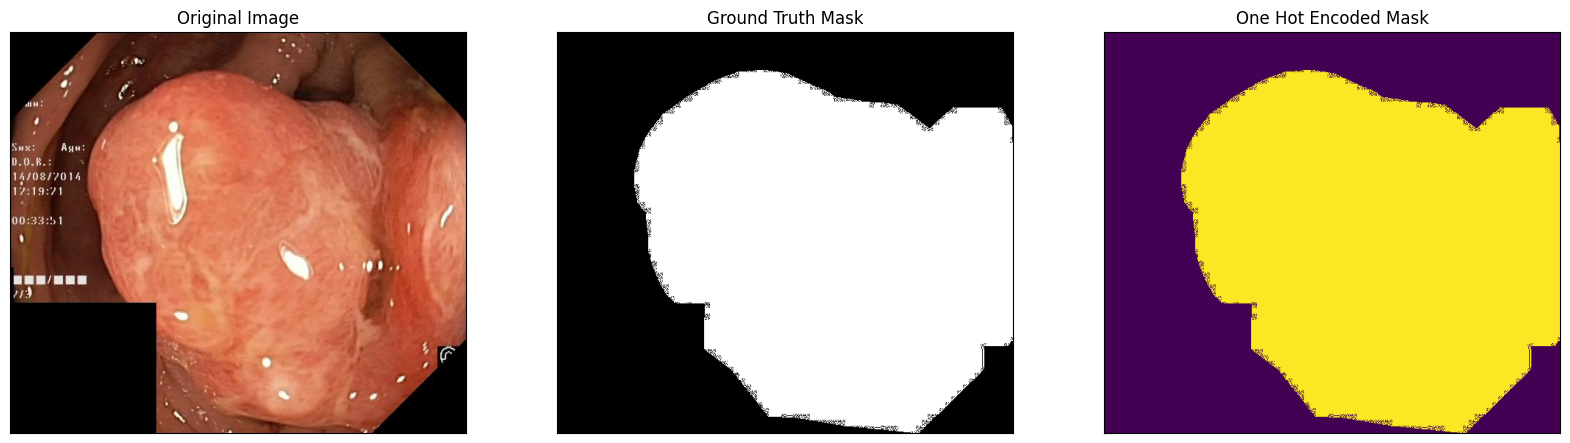

In [121]:
unet_plus_resnet.load_testset_and_visualize()

In [122]:
unet_plus_resnet.evaluation()

valid: 100%|██████████| 100/100 [00:07<00:00, 13.67it/s, dice_loss - 0.1361, iou_score - 0.9096]
Evaluation on Test Data: 
Mean IoU Score: 0.9096
Mean Dice Loss: 0.1361


In [123]:
res = unet_plus_resnet.visualize_train__loss_vs_score()
res

,0,1,2,3,4,5,6,7,8,9
dice_loss,0.391008,0.323654,0.290263,0.256632,0.222573,0.196582,0.173483,0.154353,0.140349,0.128133
iou_score,0.616139,0.756759,0.873124,0.898570,0.912629,0.922143,0.934390,0.942297,0.942506,0.944347


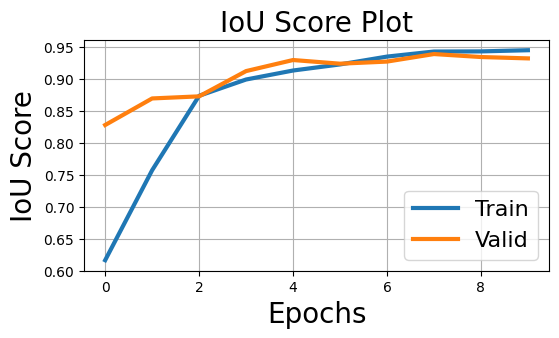

In [124]:
unet_plus_resnet.plot_iou_score_during_training()

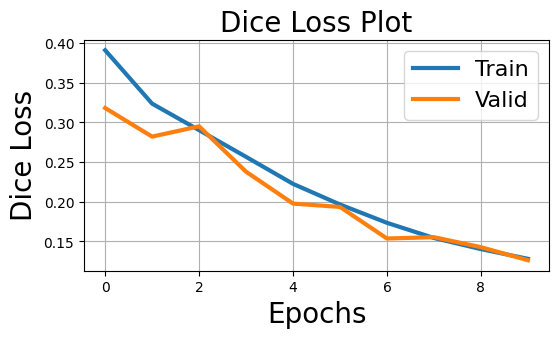

In [125]:
unet_plus_resnet.plot_dice_loss_during_training()

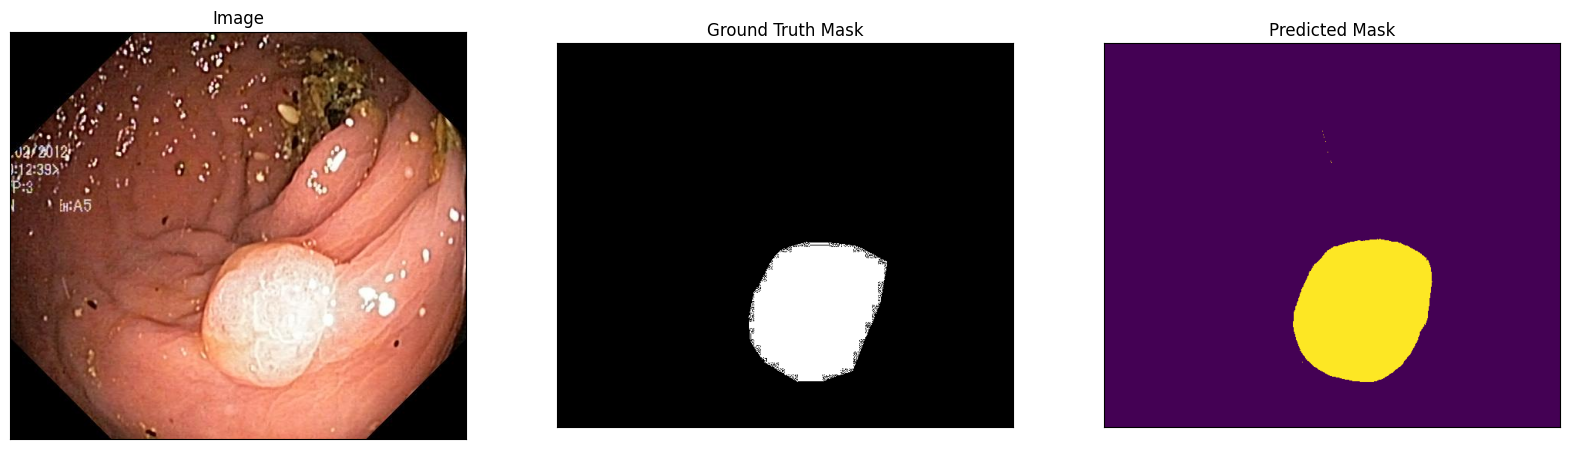

In [126]:
unet_plus_resnet.visualize_predicted_result()

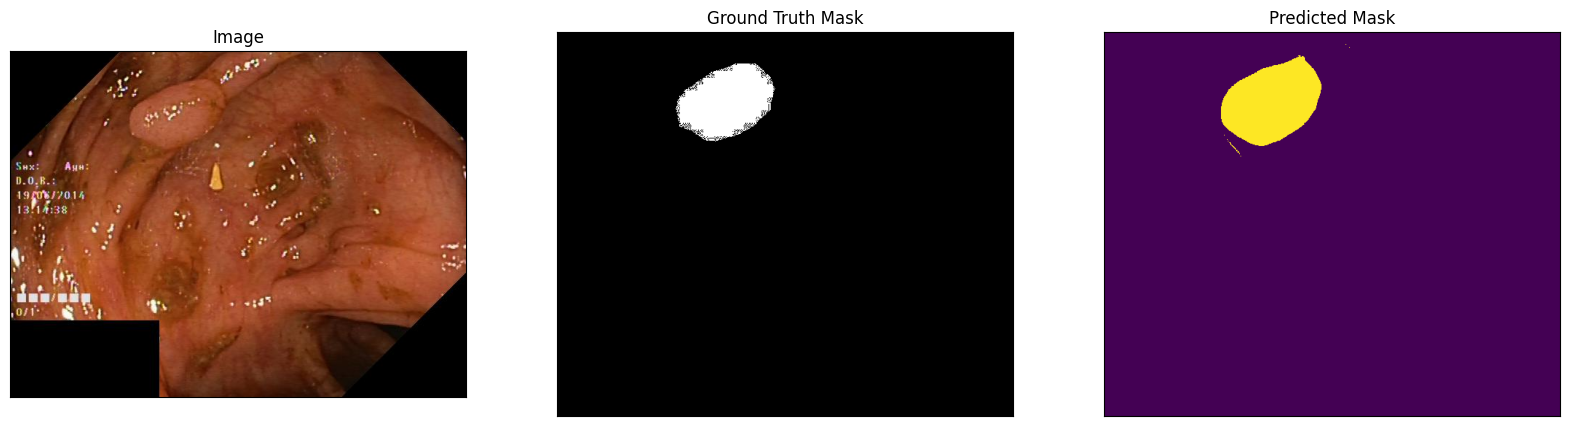

In [127]:
unet_plus_resnet.visualize_predicted_result()

#### UNET Wth MobileNet


In [128]:
unet_plus_MBNet = BaseModel('unet_plus_MBNet', smp.Unet, 'mobilenet_v2')

In [129]:
unet_plus_MBNet.init_model()

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

In [130]:
unet_plus_MBNet.build_trian_and_valid_loader()

/tmp/ipykernel_803/1227201389.py:3: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(height=512, width=608,
/tmp/ipykernel_803/1227201389.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(height=512, width=608,


In [131]:
unet_plus_MBNet.set_model_training_params()

In [132]:
unet_plus_MBNet.init_train_and_valid_epoch()

In [133]:
unet_plus_MBNet.train()


Epoch: 0
valid: 100%|██████████| 7/7 [00:05<00:00,  1.39it/s, dice_loss - 0.3037, iou_score - 0.8221]
Model saved!

Epoch: 1
valid: 100%|██████████| 7/7 [00:04<00:00,  1.59it/s, dice_loss - 0.2462, iou_score - 0.862]
Model saved!

Epoch: 2
valid: 100%|██████████| 7/7 [00:05<00:00,  1.31it/s, dice_loss - 0.2023, iou_score - 0.9058]
Model saved!

Epoch: 3
valid: 100%|██████████| 7/7 [00:04<00:00,  1.57it/s, dice_loss - 0.179, iou_score - 0.9189]
Model saved!

Epoch: 4
valid: 100%|██████████| 7/7 [00:05<00:00,  1.32it/s, dice_loss - 0.1538, iou_score - 0.9215]
Model saved!

Epoch: 5
valid: 100%|██████████| 7/7 [00:04<00:00,  1.56it/s, dice_loss - 0.1301, iou_score - 0.9293]
Model saved!

Epoch: 6
valid: 100%|██████████| 7/7 [00:04<00:00,  1.43it/s, dice_loss - 0.1117, iou_score - 0.9345]
Model saved!

Epoch: 7
valid: 100%|██████████| 7/7 [00:04<00:00,  1.58it/s, dice_loss - 0.1035, iou_score - 0.9349]
Model saved!

Epoch: 8
valid: 100%|██████████| 7/7 [00:04<00:00,  1.52it/s, dice_loss -

In [135]:
unet_plus_MBNet.best_model = torch.load(
    '/content/' + unet_plus_MBNet.model_name + '_best_model.pth', map_location=unet_plus_MBNet.DEVICE, weights_only=False)

/tmp/ipykernel_803/1227201389.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(height=512, width=608,


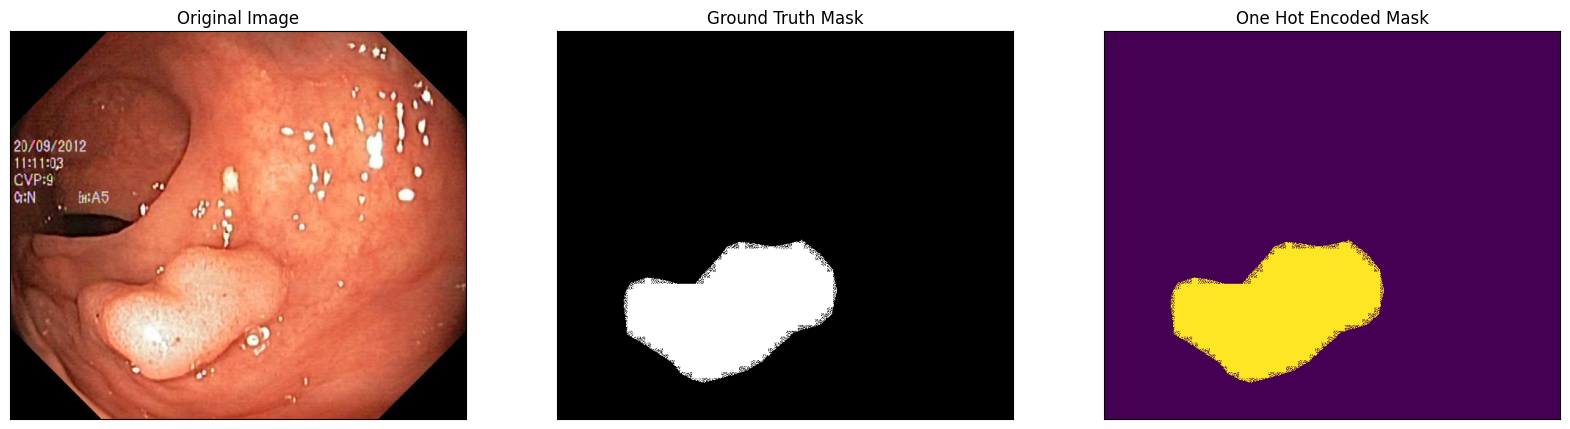

In [136]:
unet_plus_MBNet.load_testset_and_visualize()

In [137]:
unet_plus_MBNet.evaluation()

valid: 100%|██████████| 100/100 [00:06<00:00, 15.14it/s, dice_loss - 0.09228, iou_score - 0.9121]
Evaluation on Test Data: 
Mean IoU Score: 0.9121
Mean Dice Loss: 0.0923


In [138]:
res = unet_plus_MBNet.visualize_train__loss_vs_score()
res

,0,1,2,3,4,5,6,7,8,9
dice_loss,0.370602,0.274389,0.226340,0.194570,0.165025,0.142142,0.122343,0.104028,0.089151,0.080355
iou_score,0.685277,0.833355,0.866403,0.897566,0.913925,0.920225,0.923933,0.934023,0.942553,0.940683


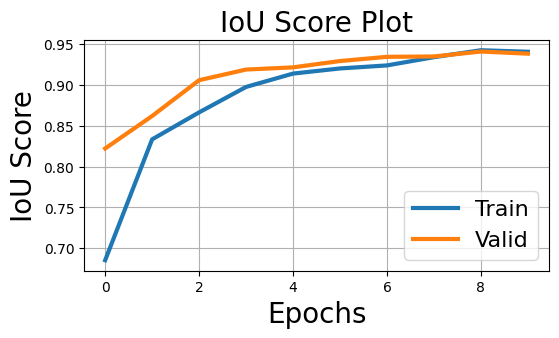

In [139]:
unet_plus_MBNet.plot_iou_score_during_training()

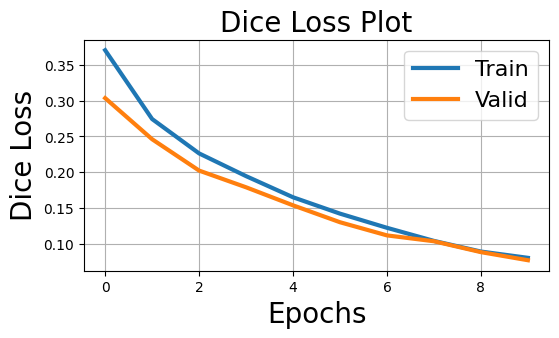

In [140]:
unet_plus_MBNet.plot_dice_loss_during_training()

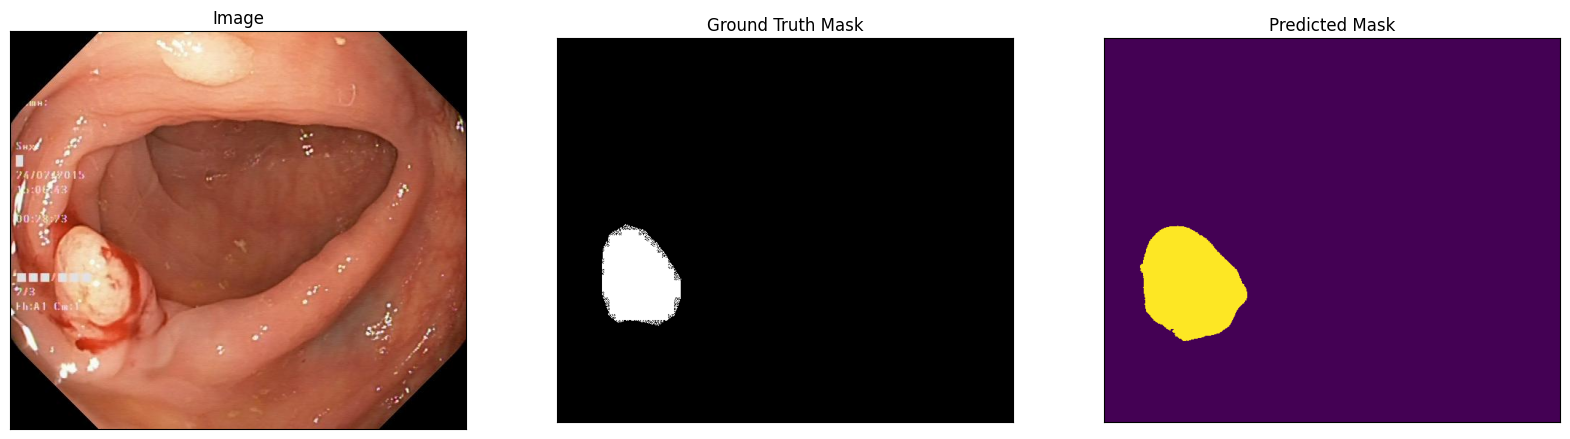

In [141]:
unet_plus_MBNet.visualize_predicted_result()

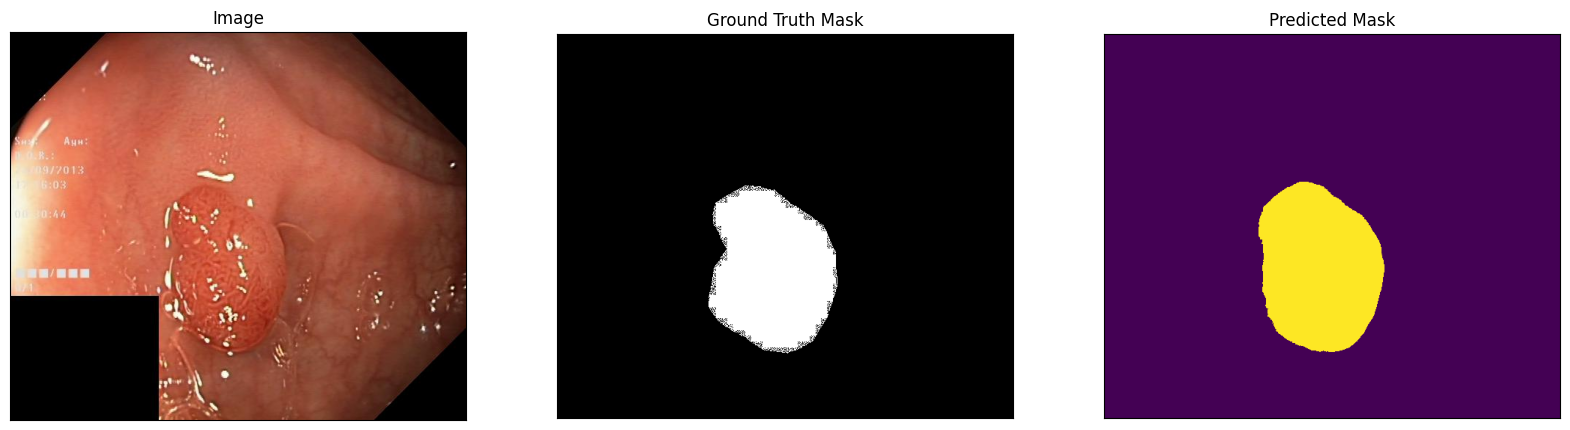

In [142]:
unet_plus_MBNet.visualize_predicted_result()

### UNET++


#### UNET++ With Resnet


In [143]:
unet_plus_plus_plus_resnet = BaseModel(
    'unet_plus_plus_plus_resnet', smp.UnetPlusPlus, 'resnet50')

In [144]:
unet_plus_plus_plus_resnet.init_model()

In [145]:
unet_plus_plus_plus_resnet.build_trian_and_valid_loader(batch_size=4)

/tmp/ipykernel_803/1227201389.py:3: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(height=512, width=608,
/tmp/ipykernel_803/1227201389.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(height=512, width=608,


In [146]:
unet_plus_plus_plus_resnet.set_model_training_params(n_epoch=7)

In [147]:
unet_plus_plus_plus_resnet.init_train_and_valid_epoch()

In [148]:
unet_plus_plus_plus_resnet.train()


Epoch: 0
valid: 100%|██████████| 25/25 [00:15<00:00,  1.59it/s, dice_loss - 0.1879, iou_score - 0.7644]
Model saved!

Epoch: 1
valid: 100%|██████████| 25/25 [00:15<00:00,  1.61it/s, dice_loss - 0.1283, iou_score - 0.8979]
Model saved!

Epoch: 2
valid: 100%|██████████| 25/25 [00:15<00:00,  1.62it/s, dice_loss - 0.08633, iou_score - 0.9031]
Model saved!

Epoch: 3
valid: 100%|██████████| 25/25 [00:15<00:00,  1.60it/s, dice_loss - 0.07117, iou_score - 0.9057]
Model saved!

Epoch: 4
valid: 100%|██████████| 25/25 [00:15<00:00,  1.61it/s, dice_loss - 0.06137, iou_score - 0.9131]
Model saved!

Epoch: 5
valid: 100%|██████████| 25/25 [00:15<00:00,  1.61it/s, dice_loss - 0.05107, iou_score - 0.9233]
Model saved!

Epoch: 6
valid: 100%|██████████| 25/25 [00:15<00:00,  1.59it/s, dice_loss - 0.0415, iou_score - 0.9362]
Model saved!
38.05030004831668 minuates


In [150]:
unet_plus_plus_plus_resnet.best_model = torch.load(
    '/content/' + unet_plus_plus_plus_resnet.model_name + '_best_model.pth', map_location=unet_plus_plus_plus_resnet.DEVICE, weights_only=False)

/tmp/ipykernel_803/1227201389.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  album.Resize(height=512, width=608,


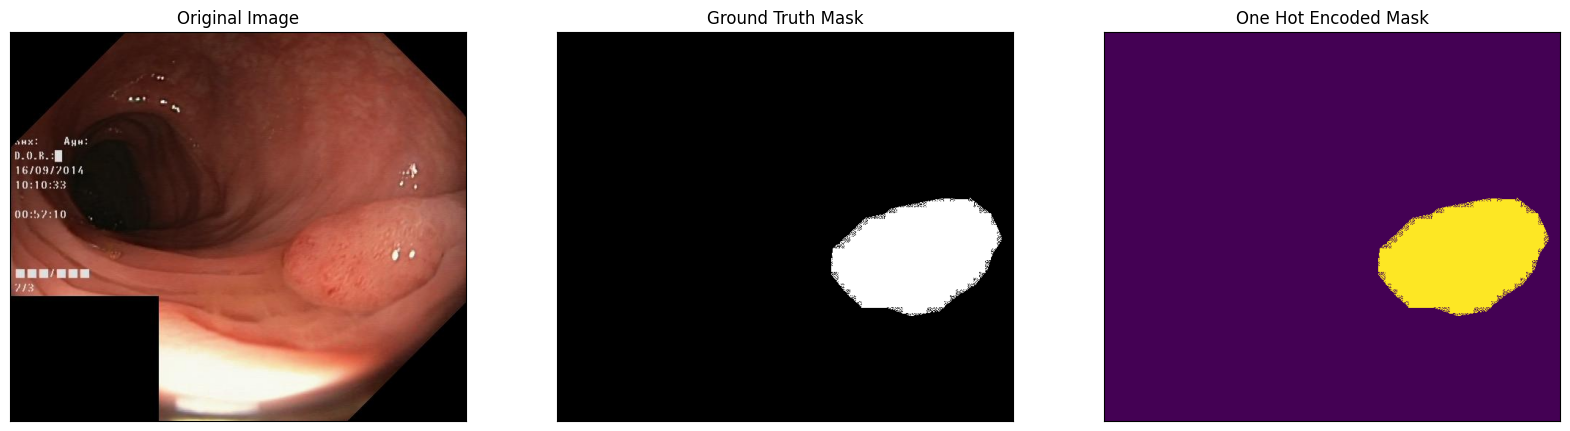

In [151]:
unet_plus_plus_plus_resnet.load_testset_and_visualize()

In [152]:
unet_plus_plus_plus_resnet.evaluation()

valid: 100%|██████████| 100/100 [00:15<00:00,  6.46it/s, dice_loss - 0.06085, iou_score - 0.9078]
Evaluation on Test Data: 
Mean IoU Score: 0.9078
Mean Dice Loss: 0.0608


In [153]:
res = unet_plus_plus_plus_resnet.visualize_train__loss_vs_score()
res

,0,1,2,3,4,5,6
dice_loss,0.261063,0.159881,0.110371,0.082600,0.069531,0.059055,0.057023
iou_score,0.701394,0.808280,0.883998,0.894822,0.900978,0.910321,0.908461


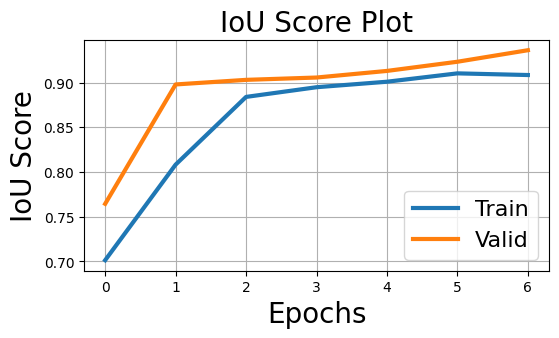

In [154]:
unet_plus_plus_plus_resnet.plot_iou_score_during_training()

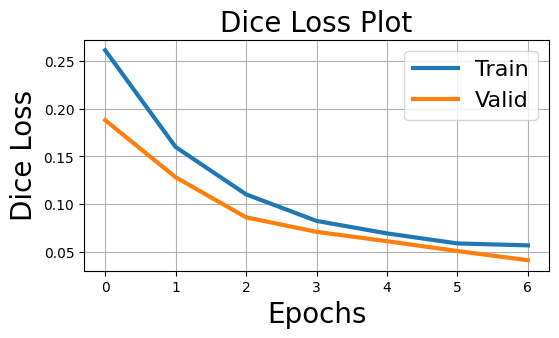

In [155]:
unet_plus_plus_plus_resnet.plot_dice_loss_during_training()

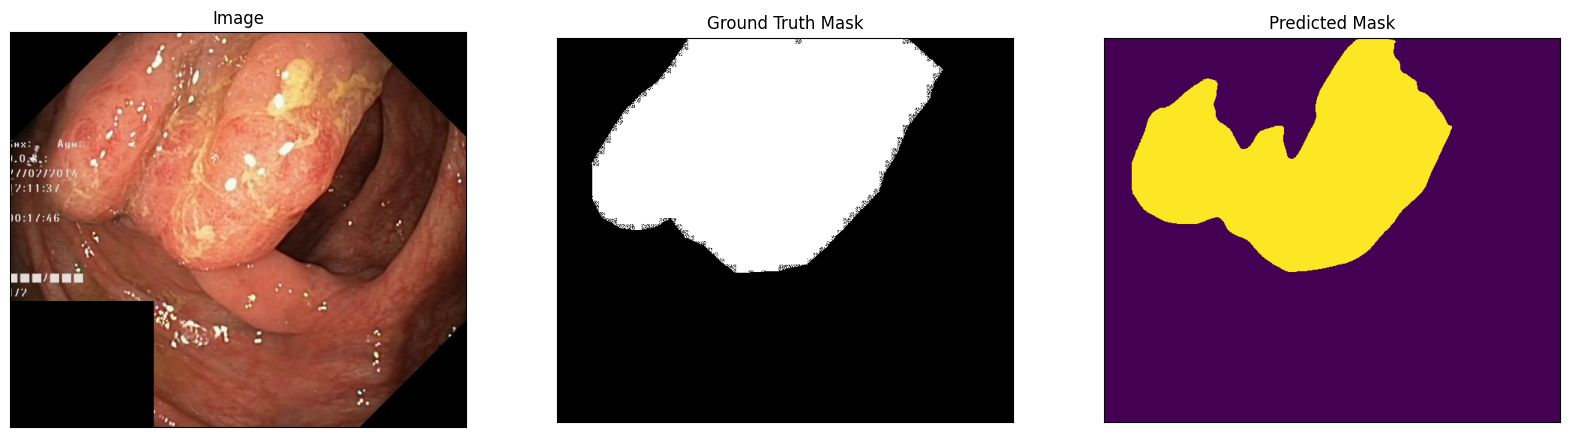

In [156]:
unet_plus_plus_plus_resnet.visualize_predicted_result()

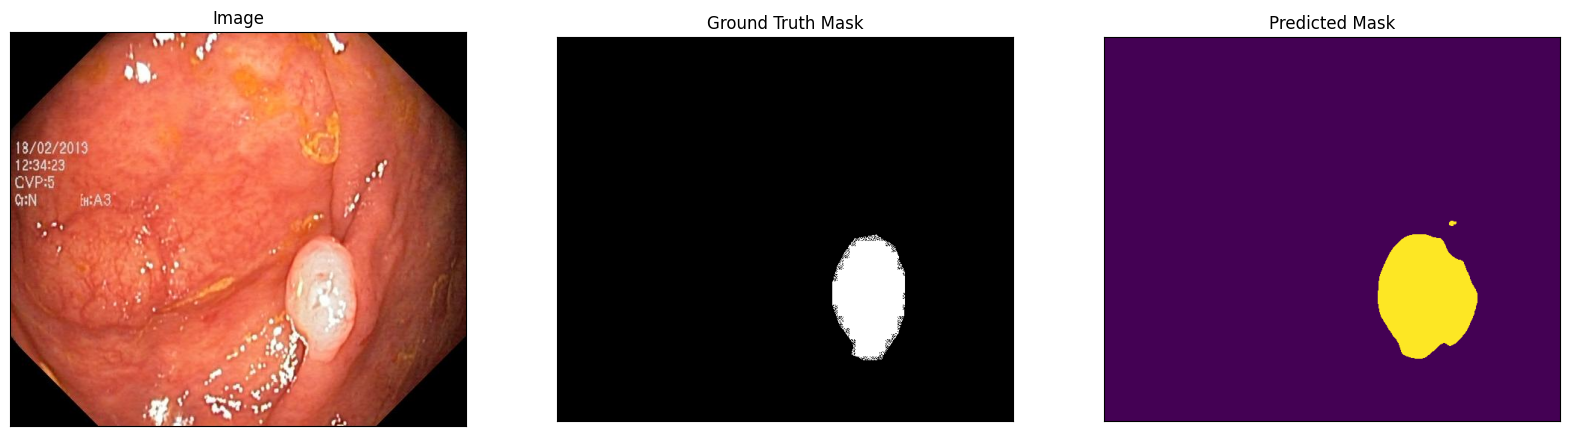

In [157]:
unet_plus_plus_plus_resnet.visualize_predicted_result()

#### Unet++ with MobileNet


In [ ]:
unet_plus_plus_plus_MBNet = BaseModel(
    'unet_plus_plus_plus_MBNet', smp.UnetPlusPlus, 'mobilenet_v2')

In [ ]:
unet_plus_plus_plus_MBNet.init_model()

In [ ]:
unet_plus_plus_plus_MBNet.build_trian_and_valid_loader(batch_size=4)

In [ ]:
unet_plus_plus_plus_MBNet.set_model_training_params(n_epoch=7)

In [ ]:
unet_plus_plus_plus_MBNet.init_train_and_valid_epoch()

In [ ]:
unet_plus_plus_plus_MBNet.train()

In [ ]:
unet_plus_plus_plus_MBNet.load_best_model()

In [ ]:
unet_plus_plus_plus_MBNet.load_testset_and_visualize()

In [ ]:
unet_plus_plus_plus_MBNet.evaluation()

In [ ]:
res = unet_plus_plus_plus_MBNet.visualize_train__loss_vs_score()
res

In [ ]:
unet_plus_plus_plus_MBNet.plot_iou_score_during_training()

In [ ]:
unet_plus_plus_plus_MBNet.plot_dice_loss_during_training()

In [ ]:
unet_plus_plus_plus_MBNet.visualize_predicted_result()

In [ ]:
unet_plus_plus_plus_MBNet.visualize_predicted_result()

### PSPNet


#### PSPNet With Resnet


In [ ]:
pspnet_plus_resnet = BaseModel('pspnet_plus_resnet', smp.PSPNet, 'resnet50')

In [ ]:
pspnet_plus_resnet.init_model()

In [ ]:
pspnet_plus_resnet.build_trian_and_valid_loader()

In [ ]:
pspnet_plus_resnet.set_model_training_params()

In [ ]:
pspnet_plus_resnet.init_train_and_valid_epoch()

In [ ]:
pspnet_plus_resnet.train()

In [ ]:
pspnet_plus_resnet.load_best_model()

In [ ]:
pspnet_plus_resnet.load_testset_and_visualize()

In [ ]:
pspnet_plus_resnet.evaluation()

In [ ]:
res = pspnet_plus_resnet.visualize_train__loss_vs_score()
res

In [ ]:
pspnet_plus_resnet.plot_iou_score_during_training()

In [ ]:
pspnet_plus_resnet.plot_dice_loss_during_training()

In [ ]:
pspnet_plus_resnet.visualize_predicted_result()

In [ ]:
pspnet_plus_resnet.visualize_predicted_result()

#### PSPNet With MobileNet


In [ ]:
pspnet_plus_MBNET = BaseModel('pspnet_plus_MBNET', smp.PSPNet, 'mobilenet_v2')

In [ ]:
pspnet_plus_MBNET.init_model()

In [ ]:
pspnet_plus_MBNET.build_trian_and_valid_loader()

In [ ]:
pspnet_plus_MBNET.set_model_training_params()

In [ ]:
pspnet_plus_MBNET.init_train_and_valid_epoch()

In [ ]:
pspnet_plus_MBNET.train()

In [ ]:
pspnet_plus_MBNET.load_best_model()

In [ ]:
pspnet_plus_MBNET.load_testset_and_visualize()

In [ ]:
pspnet_plus_MBNET.evaluation()

In [ ]:
res = pspnet_plus_MBNET.visualize_train__loss_vs_score()
res

In [ ]:
pspnet_plus_MBNET.plot_iou_score_during_training()

In [ ]:
pspnet_plus_MBNET.plot_dice_loss_during_training()

In [ ]:
pspnet_plus_MBNET.visualize_predicted_result()

### 4. DeepLabV3Plus


#### DeepLabV3Plus with ResNet


In [ ]:
dlv3p_plus_resnet = BaseModel(
    'dlv3p_plus_resnet', smp.DeepLabV3Plus, 'resnet50')

In [ ]:
dlv3p_plus_resnet.init_model()

In [ ]:
dlv3p_plus_resnet.build_trian_and_valid_loader()

In [ ]:
dlv3p_plus_resnet.set_model_training_params()

In [ ]:
dlv3p_plus_resnet.init_train_and_valid_epoch()

In [ ]:
dlv3p_plus_resnet.train()

In [ ]:
dlv3p_plus_resnet.load_best_model()

In [ ]:
dlv3p_plus_resnet.load_testset_and_visualize()

In [ ]:
dlv3p_plus_resnet.evaluation()

In [ ]:
res = dlv3p_plus_resnet.visualize_train__loss_vs_score()
res

In [ ]:
dlv3p_plus_resnet.plot_iou_score_during_training()

In [ ]:
dlv3p_plus_resnet.plot_dice_loss_during_training()

In [ ]:
dlv3p_plus_resnet.visualize_predicted_result()

In [ ]:
dlv3p_plus_resnet.visualize_predicted_result()

#### DeepLabV3Plus With MobileNet


In [ ]:
dlv3p_plus_MBNet = BaseModel(
    'dlv3p_plus_MBNet', smp.DeepLabV3Plus, 'mobilenet_v2')

In [ ]:
dlv3p_plus_MBNet.init_model()

In [ ]:
dlv3p_plus_MBNet.build_trian_and_valid_loader()

In [ ]:
dlv3p_plus_MBNet.set_model_training_params()

In [ ]:
dlv3p_plus_MBNet.init_train_and_valid_epoch()

In [ ]:
dlv3p_plus_MBNet.train()

In [ ]:
dlv3p_plus_MBNet.load_best_model()

In [ ]:
dlv3p_plus_MBNet.load_testset_and_visualize()

In [ ]:
dlv3p_plus_MBNet.evaluation()

In [ ]:
res = dlv3p_plus_MBNet.visualize_train__loss_vs_score()
res

In [ ]:
dlv3p_plus_MBNet.plot_iou_score_during_training()

In [ ]:
dlv3p_plus_MBNet.plot_dice_loss_during_training()

In [ ]:
dlv3p_plus_MBNet.visualize_predicted_result()

In [ ]:
dlv3p_plus_MBNet.visualize_predicted_result()

## Final Result


In [158]:
models = ['UNet with Resnet50', 'UNet with MobileNetV2', 'UNet++ with Resnet50',
          'UNet++ with MobileNetV2', 'PSPNet with Resnet50', 'PSPNet with MobileNetV2', 'DeepLabV3Plus with Resnet50', 'DeepLabV3Plus with MobileNetV2']

models_short_names = ['UR', 'UM', 'UPR', 'UPM', 'PR', 'PM', 'DR', 'DM']


iou_scores = [0.9261, 0.9012, 0.9229, 0.9086, 0.8652, 0.7686, 0.9064, 0.9264]

dice_losses = [0.0837, 0.1028, 0.0505, 0.0582, 0.0813, 0.1414, 0.0684, 0.0571]

dice_scores = [0.9163, 0.8972, 0.9495, 0.9418, 0.9187, 0.8586, 0.9316, 0.9429]

In [159]:
def CategoricalPlot(models, values, subtitle):
    plt.figure(figsize=(14, 4))

    plt.subplot(131)
    plt.bar(models, values)
    plt.subplot(132)
    plt.scatter(models, values)
    plt.subplot(133)
    plt.plot(models, values)
    plt.suptitle(subtitle)
    plt.show()

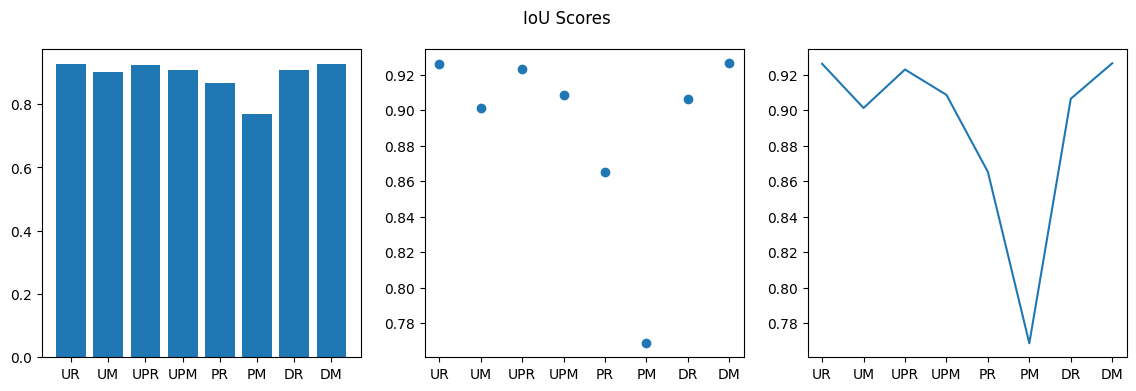

In [160]:
CategoricalPlot(models_short_names, iou_scores, "IoU Scores")

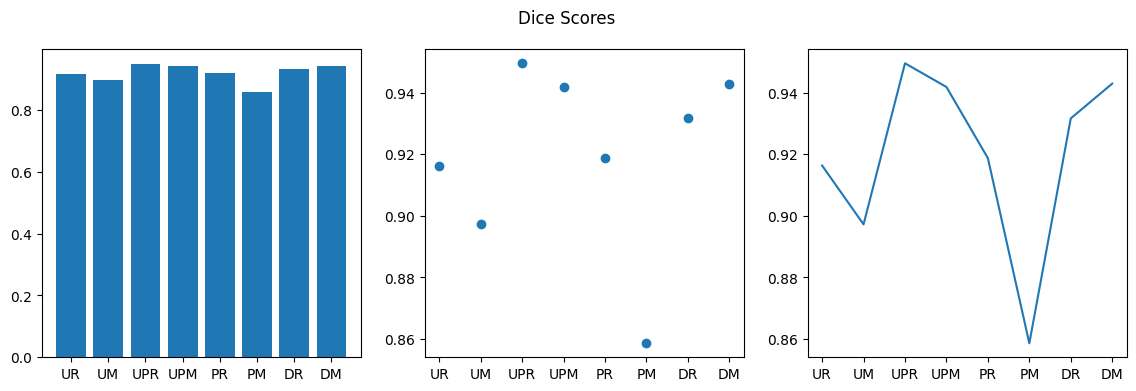

In [161]:
CategoricalPlot(models_short_names, dice_scores, "Dice Scores")

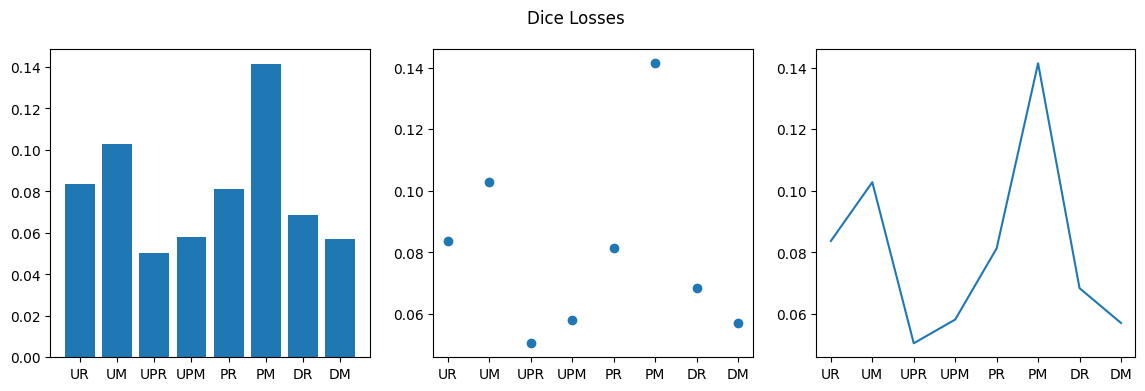

In [162]:
CategoricalPlot(models_short_names, dice_losses, "Dice Losses")

## Conclusion


#### State-of-the-art Model : UNet++ with ResNet
